In [1]:
import numpy as np
import pandas as pd 
import wrds
import os


In [ ]:
os.environ['PGPASSWORD'] = 'yourpassword' 

## WRDS CONNECTION ##

In [4]:


import wrds
db = wrds.Connection(wrds_username='rbagchi')

Loading library list...
Done


## INGEST DATA ##

In [5]:
sp500_constituents = db.raw_sql("""
    SELECT permno, start, ending
    FROM crsp.msp500list
""")

print(sp500_constituents.shape)
print(sp500_constituents.head())

(2064, 3)
   permno       start      ending
0   10006  1957-03-01  1984-07-18
1   10030  1957-03-01  1969-01-08
2   10049  1925-12-31  1932-10-01
3   10057  1957-03-01  1992-07-02
4   10078  1992-08-20  2010-01-28


In [6]:
# check available columns in crsp.dsf
cols = db.raw_sql("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'crsp'
    AND table_name = 'dsf'
    ORDER BY column_name
""")

print(cols)

   column_name
0          ask
1        askhi
2          bid
3        bidlo
4       cfacpr
5      cfacshr
6        cusip
7         date
8        hexcd
9       hsiccd
10      issuno
11      numtrd
12     openprc
13      permco
14      permno
15         prc
16         ret
17        retx
18      shrout
19         vol


In [7]:
# cell 2 - convert to string for SQL
permnos = sp500_constituents['permno'].unique().tolist()
permno_str = ','.join(map(str, permnos))

print(f"Number of unique stocks: {len(permnos)}")
print(f"First few permnos: {permnos[:5]}")

Number of unique stocks: 1936
First few permnos: [10006, 10030, 10049, 10057, 10078]


In [8]:
# permno — stock ID. 10078 is one specific stock throughout.
# date — trading date. Starts 2000-01-03 (first trading day of 2000).
# prc — raw closing price. 76.5, 71.75 etc. Take abs() before using.
# ret — daily return. -0.012107 means the stock fell 1.2% that day.
# vol — volume traded that day in shares. 15 million shares on Jan 3.
# shrout — shares outstanding in thousands. 1,561,106 × 1000 = ~1.56 billion shares.
# cfacpr — price adjustment factor. 0.5 here means there was a 2-for-1 stock split at some point — the raw price needs to be divided by 0.5 (multiplied by 2) to get the split-adjusted price.
# hexcd — exchange. 3 = NASDAQ.
crsp_data = db.raw_sql(f"""
    SELECT permno, date, prc, ret, vol, 
           shrout, cfacpr, hexcd
    FROM crsp.dsf
    WHERE permno IN ({permno_str})
    AND date BETWEEN '2000-01-01' AND '2024-12-31'
""")


In [9]:

print(crsp_data.shape)
print(crsp_data.tail(100))

(4894181, 8)
        permno        date        prc       ret         vol     shrout  \
394081   93436  2024-08-09      200.0  0.005834  58358024.0  3194640.0   
394082   93436  2024-08-12  197.49001  -0.01255  63901440.0  3194640.0   
394083   93436  2024-08-13     207.83  0.052357  76002458.0  3194640.0   
394084   93436  2024-08-14     201.38 -0.031035  69917072.0  3194640.0   
394085   93436  2024-08-15     214.14  0.063363  89426567.0  3194640.0   
...        ...         ...        ...       ...         ...        ...   
394176   93436  2024-12-24     462.28  0.073572  59351506.0  3210060.0   
394177   93436  2024-12-26     454.13  -0.01763  76392273.0  3210060.0   
394178   93436  2024-12-27     431.66 -0.049479  82370345.0  3210060.0   
394179   93436  2024-12-30     417.41 -0.033012  64705452.0  3210060.0   
394180   93436  2024-12-31     403.84  -0.03251  76455213.0  3210060.0   

        cfacpr  hexcd  
394081     1.0      3  
394082     1.0      3  
394083     1.0      3  
39

In [10]:


# 1. compute adjusted price
crsp_data['adj_prc'] = crsp_data['prc'].abs() / crsp_data['cfacpr']

# 2. filter to NYSE and NASDAQ only (drop AMEX - hexcd=2)
crsp_data = crsp_data[crsp_data['hexcd'].isin([1, 3])]

# 3. drop missing returns and prices
crsp_data = crsp_data.dropna(subset=['ret', 'adj_prc'])

# 4. drop zero or negative prices
crsp_data = crsp_data[crsp_data['adj_prc'] > 0]

# 5. compute market cap (shrout is in thousands)
crsp_data['mktcap'] = crsp_data['adj_prc'] * crsp_data['shrout'] * 1000

# 6. sort
crsp_data = crsp_data.sort_values(['permno', 'date'])

# sanity check
print(crsp_data.shape)
print(crsp_data.dtypes)
print(crsp_data.isnull().sum())
print(crsp_data.head())

(4872256, 10)
permno              Int64
date       string[python]
prc               Float64
ret               Float64
vol               Float64
shrout            Float64
cfacpr            Float64
hexcd               Int64
adj_prc           Float64
mktcap            Float64
dtype: object
permno     0
date       0
prc        0
ret        0
vol        4
shrout     0
cfacpr     0
hexcd      0
adj_prc    0
mktcap     0
dtype: int64
   permno        date     prc       ret         vol     shrout  cfacpr  hexcd  \
0   10078  2000-01-03    76.5 -0.012107  15270527.0  1561106.0     0.5      3   
1   10078  2000-01-04   71.75 -0.062092  21098710.0  1561106.0     0.5      3   
2   10078  2000-01-05  71.875  0.001742  30073258.0  1561106.0     0.5      3   
3   10078  2000-01-06    68.0 -0.053913  22741999.0  1561106.0     0.5      3   
4   10078  2000-01-07  71.875  0.056985  20450260.0  1561106.0     0.5      3   

   adj_prc          mktcap  
0    153.0  238849218000.0  
1    143.5  224018711000

## ROLLING RETURNS MATRIX ##

In [11]:
#Build returns Matrix
# ensure date is datetime
crsp_data['date'] = pd.to_datetime(crsp_data['date'])

# pivot to wide format — rows=dates, columns=permnos, values=returns
returns_matrix = crsp_data.pivot(index='date', columns='permno', values='ret')
mktcap_matrix = crsp_data.pivot(index='date', columns='permno', values='mktcap')

print(returns_matrix.shape)
print(returns_matrix.head())

(6289, 1159)
permno         10078     10104     10107     10108     10137     10138  \
date                                                                     
2000-01-03 -0.012107  0.054099 -0.001606  0.042105 -0.037123 -0.049069   
2000-01-04 -0.062092  -0.08836  -0.03378  0.010101  0.012048 -0.030249   
2000-01-05  0.001742 -0.052815  0.010544    0.0275  0.045238 -0.001835   
2000-01-06 -0.053913 -0.058824 -0.033498  0.041363 -0.009112  0.029412   
2000-01-07  0.056985  0.076823  0.013068  0.021028  0.002299 -0.007143   

permno         10145     10147     10225     10299  ...  92890  92988  93002  \
date                                                ...                        
2000-01-03 -0.017335  0.043478 -0.024575  0.006114  ...   <NA>   <NA>   <NA>   
2000-01-04 -0.017641 -0.057018 -0.017442  0.027778  ...   <NA>   <NA>   <NA>   
2000-01-05 -0.013468 -0.041861  0.005917  0.047297  ...   <NA>   <NA>   <NA>   
2000-01-06   0.01934 -0.032767  0.009804  0.003226  ...   <NA>   <NA

In [12]:
# last trading day of each month
rebal_dates = returns_matrix.resample('ME').last().index

print(f"Number of rebalancing dates: {len(rebal_dates)}")
print(f"First few: {rebal_dates[:5]}")

Number of rebalancing dates: 300
First few: DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30',
               '2000-05-31'],
              dtype='datetime64[ns]', name='date', freq='ME')


In [13]:
formation_window = 252
results = []

for rebal_date in rebal_dates:
    # find the closest available date in mktcap_matrix
    available_dates = mktcap_matrix.index[mktcap_matrix.index <= rebal_date]
    
    if len(available_dates) == 0:
        continue
    
    closest_date = available_dates[-1]  # last available date up to rebal_date
    
    # step 1: pick top 100 by market cap at closest date
    mktcap_snapshot = mktcap_matrix.loc[closest_date].dropna()
    top100 = mktcap_snapshot.nlargest(100).index.tolist()
    
    if len(top100) < 50:
        continue
    
    # step 2: get past 252 days of returns for those stocks
    past_dates = returns_matrix.index[returns_matrix.index <= closest_date]
    
    if len(past_dates) < formation_window:
        continue
    
    past_returns = returns_matrix.loc[
        past_dates[-formation_window:], top100
    ]
    
    # drop stocks with too many missing returns
    past_returns = past_returns.dropna(axis=1, thresh=int(0.95 * formation_window))
    past_returns = past_returns.fillna(0)
    
    if past_returns.shape[1] < 50:
        continue
    
    results.append({
        'date': rebal_date,
        'closest_date': closest_date,
        'n_stocks': past_returns.shape[1],
        'permnos': past_returns.columns.tolist(),
        'returns': past_returns.values.astype(float)
    })

print(f"Valid rebalancing periods: {len(results)}")
print(f"First period: {results[0]['date']}, stocks: {results[0]['n_stocks']}")
print(f"Last period: {results[-1]['date']}, stocks: {results[-1]['n_stocks']}")

Valid rebalancing periods: 289
First period: 2000-12-31 00:00:00, stocks: 98
Last period: 2024-12-31 00:00:00, stocks: 100


In [40]:
# SANITY CHECK 

# check a specific period looks right
sample = results[50]  # pick a random period
print(f"Date: {sample['date']}")
print(f"Number of stocks: {sample['n_stocks']}")
print(f"Returns shape: {sample['returns'].shape}")
print(f"Returns mean: {sample['returns'].mean():.6f}")
print(f"Returns std: {sample['returns'].std():.4f}")
print(f"Any NaN: {np.isnan(sample['returns']).any()}")

Date: 2005-02-28 00:00:00
Number of stocks: 99
Returns shape: (252, 99)
Returns mean: 0.000273
Returns std: 0.0154
Any NaN: False


## METHODS ##

## COVARIANCE MATRIX SAMPLE CALCULATION ##

In [14]:
import warnings
import numpy as np

# suppress the runtime warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# rerun the covariance computation cleanly
for i, period in enumerate(results):
    R = period['returns'].astype(np.float64)
    R = np.where(np.isfinite(R), R, 0.0)
    R_demeaned = R - R.mean(axis=0)
    T, N = R.shape
    Sigma_sample = (R_demeaned.T @ R_demeaned) / (T - 1)
    results[i]['Sigma_sample'] = Sigma_sample
    results[i]['returns'] = R

print("Sample covariance computed for all periods, no issues")

Sample covariance computed for all periods, no issues


# LEDOIT WOLF #

In [15]:
from sklearn.covariance import LedoitWolf

for i, period in enumerate(results):
    R = period['returns']
    
    lw = LedoitWolf()
    lw.fit(R)
    
    results[i]['Sigma_LW'] = lw.covariance_
    results[i]['shrinkage'] = lw.shrinkage_  # save shrinkage intensity too

# sanity check
print(f"LW shape: {results[50]['Sigma_LW'].shape}")
print(f"LW min eigenvalue: {np.linalg.eigvalsh(results[50]['Sigma_LW']).min():.6f}")
print(f"Shrinkage intensity: {results[50]['shrinkage']:.4f}")
print(f"LW vs sample diagonal diff: {np.diag(results[50]['Sigma_LW'] - results[50]['Sigma_sample']).mean():.8f}")

LW shape: (99, 99)
LW min eigenvalue: 0.000023
Shrinkage intensity: 0.0653
LW vs sample diagonal diff: -0.00000094


# DCC GARCH #

In [16]:
from arch import arch_model
import numpy as np

def fit_dcc_garch(returns, p=1, q=1):
    """
    Fit DCC-GARCH model to returns matrix
    returns: (T, N) numpy array
    """
    T, N = returns.shape
    
    # step 1 — fit GARCH(1,1) to each stock individually
    std_resids = np.zeros((T, N))
    vols = np.zeros((T, N))
    
    for j in range(N):
        try:
            model = arch_model(returns[:, j] * 100,  # scale for numerical stability
                             vol='GARCH', p=p, q=q, 
                             dist='normal', rescale=False)
            res = model.fit(disp='off', show_warning=False)
            vols[:, j] = res.conditional_volatility / 100
            std_resids[:, j] = (returns[:, j] / vols[:, j])
        except:
            # if GARCH fails for a stock, use rolling std
            rolling_std = np.std(returns[:, j])
            vols[:, j] = rolling_std
            std_resids[:, j] = returns[:, j] / rolling_std
    
    # step 2 — compute Q_bar (unconditional correlation of std residuals)
    Q_bar = np.cov(std_resids.T)
    
    # normalize Q_bar to correlation matrix
    d = np.sqrt(np.diag(Q_bar))
    Q_bar_corr = Q_bar / np.outer(d, d)
    
    # step 3 — DCC updating with alpha=0.05, beta=0.90
    # (simplified: fixed parameters, not estimated via MLE for speed)
    alpha = 0.05
    beta = 0.90
    
    Q = Q_bar_corr.copy()
    R_t = np.zeros((T, N, N))  # correlation matrices over time
    
    for t in range(1, T):
        z = std_resids[t-1]
        Q = (1 - alpha - beta) * Q_bar_corr + \
            alpha * np.outer(z, z) + \
            beta * Q
        
        # normalize to get correlation matrix
        d = np.sqrt(np.diag(Q))
        R_t[t] = Q / np.outer(d, d)
    
    # use last period correlation matrix
    R_last = R_t[-1]
    
    # step 4 — reconstruct covariance matrix
    # Sigma = D @ R @ D where D is diagonal of current volatilities
    D_last = np.diag(vols[-1])
    Sigma_DCC = D_last @ R_last @ D_last
    
    # ensure positive definiteness
    min_eig = np.linalg.eigvalsh(Sigma_DCC).min()
    if min_eig < 0:
        Sigma_DCC += (-min_eig + 1e-8) * np.eye(N)
    
    return Sigma_DCC

# fit DCC-GARCH for all periods
# warning: this will take a while — ~289 periods × 99 stocks
print("Fitting DCC-GARCH... this will take several minutes")

for i, period in enumerate(results):
    R = period['returns']
    results[i]['Sigma_DCC'] = fit_dcc_garch(R)
    
    if i % 20 == 0:
        print(f"Period {i}/{len(results)} done")

# sanity check
print(f"DCC shape: {results[50]['Sigma_DCC'].shape}")
print(f"DCC min eigenvalue: {np.linalg.eigvalsh(results[50]['Sigma_DCC']).min():.6f}")
print(f"DCC max eigenvalue: {np.linalg.eigvalsh(results[50]['Sigma_DCC']).max():.6f}")

Fitting DCC-GARCH... this will take several minutes
Period 0/289 done
Period 20/289 done
Period 40/289 done
Period 60/289 done
Period 80/289 done
Period 100/289 done
Period 120/289 done
Period 140/289 done
Period 160/289 done
Period 180/289 done
Period 200/289 done
Period 220/289 done
Period 240/289 done
Period 260/289 done
Period 280/289 done
DCC shape: (99, 99)
DCC min eigenvalue: 0.000005
DCC max eigenvalue: 0.006332


## KALMAN FILTER ##

In [17]:
def fit_kalman_factor(returns, n_factors=5):
    T, N = returns.shape
    K = n_factors
    
    # step 1 — PCA initialization
    R_dm = returns - returns.mean(axis=0)
    S = (R_dm.T @ R_dm) / (T - 1)
    
    eigenvalues, eigenvectors = np.linalg.eigh(S)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # loadings scaled properly
    B = eigenvectors[:, :K]  # shape (N, K) — unit norm eigenvectors
    
    # factor covariance — diagonal with top K eigenvalues
    F = np.diag(eigenvalues[:K])  # shape (K, K)
    
    # idiosyncratic variances
    Sigma_factor = B @ F @ B.T
    residual_var = np.diag(S) - np.diag(Sigma_factor)
    residual_var = np.maximum(residual_var, 1e-8)  # floor at small positive
    D = np.diag(residual_var)
    
    # step 2 — simplified Kalman filter for time-varying loadings
    Q_state = 0.0001 * np.eye(K)  # small state noise — loadings drift slowly
    
    B_t = B.copy()
    
    for t in range(T):
        r_t = returns[t]
        
        # extract factors via OLS
        try:
            f_t = np.linalg.lstsq(B_t, r_t, rcond=None)[0]
        except:
            f_t = np.zeros(K)
        
        # simplified loading update per stock
        for n in range(N):
            b_n = B_t[n]
            innov = r_t[n] - b_n @ f_t
            S_innov = b_n @ F @ b_n + D[n, n]
            
            if S_innov > 1e-10:
                K_gain = F @ f_t / S_innov
                B_t[n] = b_n + 0.001 * K_gain * innov  # small step size
    
    # step 3 — covariance from final loadings
    # recompute idiosyncratic variance with final B
    fitted = returns @ B_t @ np.linalg.pinv(B_t.T @ B_t) @ B_t.T
    residuals = returns - fitted
    D_final = np.diag(np.maximum(np.var(residuals, axis=0), 1e-8))
    
    # factor covariance from data
    factors = returns @ B_t @ np.linalg.pinv(B_t.T @ B_t)
    F_final = np.cov(factors.T)
    if F_final.ndim == 0:
        F_final = np.array([[F_final]])
    
    Sigma_Kalman = B_t @ F_final @ B_t.T + D_final
    
    # ensure positive definiteness
    min_eig = np.linalg.eigvalsh(Sigma_Kalman).min()
    if min_eig < 0:
        Sigma_Kalman += (-min_eig + 1e-8) * np.eye(N)
    
    return Sigma_Kalman

# refit
print("Refitting Kalman filter factor model...")

for i, period in enumerate(results):
    R = period['returns']
    results[i]['Sigma_Kalman'] = fit_kalman_factor(R, n_factors=5)
    
    if i % 20 == 0:
        print(f"Period {i}/{len(results)} done")

print(f"Kalman shape: {results[50]['Sigma_Kalman'].shape}")
print(f"Kalman min eigenvalue: {np.linalg.eigvalsh(results[50]['Sigma_Kalman']).min():.6f}")
print(f"Kalman max eigenvalue: {np.linalg.eigvalsh(results[50]['Sigma_Kalman']).max():.6f}")

# compare scale to other estimators
print(f"\nMax eigenvalue comparison:")
print(f"Sample:  {np.linalg.eigvalsh(results[50]['Sigma_sample']).max():.6f}")
print(f"LW:      {np.linalg.eigvalsh(results[50]['Sigma_LW']).max():.6f}")
print(f"DCC:     {np.linalg.eigvalsh(results[50]['Sigma_DCC']).max():.6f}")
print(f"Kalman:  {np.linalg.eigvalsh(results[50]['Sigma_Kalman']).max():.6f}")

Refitting Kalman filter factor model...
Period 0/289 done
Period 20/289 done
Period 40/289 done
Period 60/289 done
Period 80/289 done
Period 100/289 done
Period 120/289 done
Period 140/289 done
Period 160/289 done
Period 180/289 done
Period 200/289 done
Period 220/289 done
Period 240/289 done
Period 260/289 done
Period 280/289 done
Kalman shape: (99, 99)
Kalman min eigenvalue: 0.000028
Kalman max eigenvalue: 0.006388

Max eigenvalue comparison:
Sample:  0.006229
LW:      0.005815
DCC:     0.006332
Kalman:  0.006388


## Regime Detection using hmm ##

In [18]:
import pandas_datareader as pdr
import datetime

# pull VIX from FRED
vix = pdr.get_data_fred('VIXCLS', start='2000-01-01', end='2024-12-31')
vix.columns = ['vix']
vix = vix.dropna()

print(vix.shape)
print(vix.head())

/Users/ranitbagchi/VSCODE_data_projects/Fundamental_stat_arb/.venv_mrp/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


(6309, 1)
              vix
DATE             
2000-01-03  24.21
2000-01-04  27.01
2000-01-05  26.41
2000-01-06  25.73
2000-01-07  21.72


In [19]:
# compute daily market-level features from returns matrix
# realized vol = cross-sectional average of rolling 21-day vol
# avg pairwise correlation = average correlation across all stock pairs

market_features = []

for period in results:
    R = period['returns']  # (252, N)
    date = period['date']
    
    # 1. realized volatility — annualized std of equal-weight portfolio returns
    ew_returns = R.mean(axis=1)  # equal weight portfolio daily returns
    realized_vol = ew_returns.std() * np.sqrt(252)
    
    # 2. average pairwise correlation
    corr_matrix = np.corrcoef(R.T)  # (N, N)
    # take upper triangle (excluding diagonal)
    upper_tri = corr_matrix[np.triu_indices(corr_matrix.shape[0], k=1)]
    avg_corr = upper_tri.mean()
    
    # 3. get VIX at this date
    vix_dates = vix.index[vix.index <= date]
    if len(vix_dates) == 0:
        vix_val = np.nan
    else:
        vix_val = vix.loc[vix_dates[-1], 'vix']
    
    market_features.append({
        'date': date,
        'realized_vol': realized_vol,
        'avg_corr': avg_corr,
        'vix': vix_val
    })

features_df = pd.DataFrame(market_features)
features_df = features_df.dropna()

print(features_df.shape)
print(features_df.describe())
print(features_df.head())

(289, 4)
                                date  realized_vol    avg_corr         vix
count                            289    289.000000  289.000000  289.000000
mean   2012-12-29 22:20:20.761245696      0.179464    0.348417   19.818028
min              2000-12-31 00:00:00      0.066487    0.134033    9.510000
25%              2006-12-31 00:00:00      0.119022    0.257785   13.840000
50%              2012-12-31 00:00:00      0.154630    0.345391   17.520000
75%              2018-12-31 00:00:00      0.214444    0.411594   23.540000
max              2024-12-31 00:00:00      0.493688    0.620512   59.890000
std                              NaN      0.084487    0.116143    8.052085
        date  realized_vol  avg_corr    vix
0 2000-12-31      0.245554  0.151652  26.85
1 2001-01-31      0.248676  0.142020  22.02
2 2001-02-28      0.228214  0.134033  28.35
3 2001-03-31      0.218501  0.134240  28.64
4 2001-04-30      0.237477  0.146701  25.48


In [20]:
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import numpy as np

# prepare feature matrix
feature_cols = ['realized_vol', 'avg_corr', 'vix']
X = features_df[feature_cols].values  # shape (289, 3)

# standardize features — HMM works better with standardized inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit HMM with 3 states
# option 1 — try 2 states
np.random.seed(42)
hmm_2 = GaussianHMM(
    n_components=2,
    covariance_type='full',
    n_iter=1000,
    random_state=42
)
hmm_2.fit(X_scaled)

posteriors_2 = hmm_2.predict_proba(X_scaled)
labels_2 = hmm_2.predict(X_scaled)

features_df['regime_2state'] = labels_2
print("2-state regime counts:", np.bincount(labels_2))
print("\nMean features per regime (2-state):")
print(features_df.groupby('regime_2state')[feature_cols].mean())

2-state regime counts: [227  62]

Mean features per regime (2-state):
               realized_vol  avg_corr        vix
regime_2state                                   
0                  0.145576  0.308960  17.230617
1                  0.303537  0.492879  29.291290


In [21]:
stressed_dates = features_df[features_df['regime_2state'] == 1]['date']
print("Stressed regime dates:")
print(stressed_dates.values)

Stressed regime dates:
['2002-07-31T00:00:00.000000000' '2002-08-31T00:00:00.000000000'
 '2002-09-30T00:00:00.000000000' '2002-10-31T00:00:00.000000000'
 '2002-11-30T00:00:00.000000000' '2002-12-31T00:00:00.000000000'
 '2003-01-31T00:00:00.000000000' '2003-02-28T00:00:00.000000000'
 '2003-03-31T00:00:00.000000000' '2003-04-30T00:00:00.000000000'
 '2003-05-31T00:00:00.000000000' '2003-06-30T00:00:00.000000000'
 '2003-07-31T00:00:00.000000000' '2003-08-31T00:00:00.000000000'
 '2008-09-30T00:00:00.000000000' '2008-10-31T00:00:00.000000000'
 '2008-11-30T00:00:00.000000000' '2008-12-31T00:00:00.000000000'
 '2009-01-31T00:00:00.000000000' '2009-02-28T00:00:00.000000000'
 '2009-03-31T00:00:00.000000000' '2009-04-30T00:00:00.000000000'
 '2009-05-31T00:00:00.000000000' '2009-06-30T00:00:00.000000000'
 '2009-07-31T00:00:00.000000000' '2009-08-31T00:00:00.000000000'
 '2009-09-30T00:00:00.000000000' '2009-10-31T00:00:00.000000000'
 '2009-11-30T00:00:00.000000000' '2009-12-31T00:00:00.000000000'
 '

In [22]:
# use 2-state HMM going forward
posteriors_2state = hmm_2.predict_proba(X_scaled)  # shape (289, 2)
features_df['regime'] = labels_2

# add regime posteriors to each results period
for i, period in enumerate(results):
    date = period['date']
    
    # find matching index in features_df
    idx = features_df[features_df['date'] == date].index
    
    if len(idx) > 0:
        pi = posteriors_2state[idx[0]]  # [p_calm, p_stressed]
        results[i]['pi_calm'] = pi[0]
        results[i]['pi_stressed'] = pi[1]
        results[i]['regime'] = labels_2[idx[0]]
    else:
        results[i]['pi_calm'] = 0.5
        results[i]['pi_stressed'] = 0.5
        results[i]['regime'] = 0

# verify
print("Regime posteriors added to results")
print(f"Sample period 50:")
print(f"  Date: {results[50]['date']}")
print(f"  P(calm): {results[50]['pi_calm']:.4f}")
print(f"  P(stressed): {results[50]['pi_stressed']:.4f}")
print(f"  Regime: {results[50]['regime']}")

# check coverage
missing = sum(1 for r in results if 'pi_calm' not in r)
print(f"Periods missing posteriors: {missing}")

Regime posteriors added to results
Sample period 50:
  Date: 2005-02-28 00:00:00
  P(calm): 1.0000
  P(stressed): 0.0000
  Regime: 0
Periods missing posteriors: 0


In [31]:
# build adaptive and equal blend (original)
for i, period in enumerate(results):
    pi_calm = period['pi_calm']
    pi_stressed = period['pi_stressed']
    
    Sigma_LW = period['Sigma_LW']
    Sigma_DCC = period['Sigma_DCC']
    Sigma_Kalman = period['Sigma_Kalman']
    
    # original adaptive
    results[i]['Sigma_adaptive'] = (pi_calm * Sigma_LW + 
                                    (pi_stressed / 2) * Sigma_DCC + 
                                    (pi_stressed / 2) * Sigma_Kalman)
    
    # equal weight ablation
    results[i]['Sigma_equal'] = (Sigma_LW + Sigma_DCC + Sigma_Kalman) / 3
    
    # v2 — calm→LW, stressed→DCC
    results[i]['Sigma_adaptive_v2'] = (pi_calm * Sigma_LW + 
                                       pi_stressed * Sigma_DCC)
    
    # v3 — calm→LW, stressed→70%DCC+30%Kalman
    results[i]['Sigma_adaptive_v3'] = (pi_calm * Sigma_LW + 
                                       pi_stressed * 0.7 * Sigma_DCC +
                                       pi_stressed * 0.3 * Sigma_Kalman)

print("All adaptive estimators built")

All adaptive estimators built


In [79]:
# you have 5 covariance matrices per period:
# 1. Sigma_sample  — naive baseline
# 2. Sigma_LW      — static shrinkage
# 3. Sigma_DCC     — dynamic continuous
# 4. Sigma_Kalman  — dynamic factor
# 5. Sigma_adaptive — your BMA framework
# 6. Sigma_equal   — ablation (naive combination)

# verify all 6 exist for period 50
period = results[50]
estimators = ['Sigma_sample', 'Sigma_LW', 'Sigma_DCC', 
              'Sigma_Kalman', 'Sigma_adaptive', 'Sigma_equal']

for name in estimators:
    Sigma = period[name]
    min_eig = np.linalg.eigvalsh(Sigma).min()
    max_eig = np.linalg.eigvalsh(Sigma).max()
    print(f"{name:20s} min_eig={min_eig:.6f}  max_eig={max_eig:.6f}")

Sigma_sample         min_eig=0.000008  max_eig=0.006229
Sigma_LW             min_eig=0.000023  max_eig=0.005815
Sigma_DCC            min_eig=0.000005  max_eig=0.006332
Sigma_Kalman         min_eig=0.000028  max_eig=0.006388
Sigma_adaptive       min_eig=0.000023  max_eig=0.005815
Sigma_equal          min_eig=0.000023  max_eig=0.005902


## PORTFOLIO CONSTRUCTION ##

In [26]:
from scipy.optimize import minimize

def min_variance_weights(Sigma, max_weight=0.05):
    """Minimum variance portfolio with weight constraints"""
    N = Sigma.shape[0]
    
    def portfolio_variance(w):
        return w @ Sigma @ w
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, max_weight)] * N  # long only, max 5% per stock
    w0 = np.ones(N) / N  # equal weight starting point
    
    result = minimize(portfolio_variance, w0,
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints,
                     options={'ftol': 1e-9, 'maxiter': 1000})
    
    if result.success:
        return result.x
    else:
        return np.ones(N) / N  # fallback to equal weight

def risk_parity_weights(Sigma, max_weight=0.05):
    """Risk parity — equal risk contribution"""
    N = Sigma.shape[0]
    
    def risk_parity_obj(w):
        port_var = w @ Sigma @ w
        marginal_risk = Sigma @ w
        risk_contrib = w * marginal_risk / port_var
        return np.sum((risk_contrib - 1/N) ** 2)
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, max_weight)] * N
    w0 = np.ones(N) / N
    
    result = minimize(risk_parity_obj, w0,
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints,
                     options={'ftol': 1e-9, 'maxiter': 1000})
    
    if result.success:
        return result.x
    else:
        return np.ones(N) / N

def max_sharpe_weights(Sigma, mu=None, max_weight=0.05):
    """Maximum Sharpe ratio portfolio"""
    N = Sigma.shape[0]
    
    # if no expected returns provided, use equal expected returns
    # this reduces to minimum variance — fine for our purposes
    if mu is None:
        mu = np.ones(N) / N
    
    def neg_sharpe(w):
        port_ret = w @ mu
        port_vol = np.sqrt(w @ Sigma @ w)
        if port_vol < 1e-10:
            return 0
        return -port_ret / port_vol
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, max_weight)] * N
    w0 = np.ones(N) / N
    
    result = minimize(neg_sharpe, w0,
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints,
                     options={'ftol': 1e-9, 'maxiter': 1000})
    
    if result.success:
        return result.x
    else:
        return np.ones(N) / N

# test on period 50
period = results[50]
Sigma = period['Sigma_LW']

w_mv = min_variance_weights(Sigma)
w_rp = risk_parity_weights(Sigma)
w_ms = max_sharpe_weights(Sigma)

print(f"Min variance weights sum: {w_mv.sum():.4f}")
print(f"Risk parity weights sum: {w_rp.sum():.4f}")
print(f"Max Sharpe weights sum: {w_ms.sum():.4f}")
print(f"Min variance max weight: {w_mv.max():.4f}")
print(f"Risk parity max weight: {w_rp.max():.4f}")
print(f"Portfolio variance (MV): {w_mv @ Sigma @ w_mv:.8f}")
print(f"Portfolio variance (RP): {w_rp @ Sigma @ w_rp:.8f}")
print(f"Portfolio variance (EW): {(np.ones(99)/99) @ Sigma @ (np.ones(99)/99):.8f}")

Min variance weights sum: 1.0000
Risk parity weights sum: 1.0000
Max Sharpe weights sum: 1.0000
Min variance max weight: 0.0500
Risk parity max weight: 0.0307
Portfolio variance (MV): 0.00002428
Portfolio variance (RP): 0.00004012
Portfolio variance (EW): 0.00005001


In [32]:
all_estimator_names = ['Sigma_sample', 'Sigma_LW', 'Sigma_DCC', 
                       'Sigma_Kalman', 'Sigma_adaptive', 'Sigma_equal',
                       'Sigma_adaptive_v2', 'Sigma_adaptive_v3']

portfolio_types = ['mv', 'rp', 'ms']

print("Building portfolios for all estimators...")

for i, period in enumerate(results):
    results[i]['weights'] = {}
    
    for est_name in all_estimator_names:
        Sigma = period[est_name]
        results[i]['weights'][f'{est_name}_mv'] = min_variance_weights(Sigma)
        results[i]['weights'][f'{est_name}_rp'] = risk_parity_weights(Sigma)
        results[i]['weights'][f'{est_name}_ms'] = max_sharpe_weights(Sigma)
    
    if i % 50 == 0:
        print(f"Period {i}/{len(results)} done")

print("All portfolios built")

Building portfolios for all estimators...
Period 0/289 done
Period 50/289 done
Period 100/289 done
Period 150/289 done
Period 200/289 done
Period 250/289 done
All portfolios built


## trying version 2 ##

In [33]:
portfolio_returns = {f'{est}_{pt}': [] 
                    for est in all_estimator_names 
                    for pt in portfolio_types}

dates_out = []

print("Running walk-forward evaluation...")

for i in range(len(results) - 1):
    period = results[i]
    next_period = results[i + 1]
    current_date = period['date']
    next_date = next_period['date']
    
    future_dates = returns_matrix.index[
        (returns_matrix.index > current_date) & 
        (returns_matrix.index <= next_date)
    ]
    
    if len(future_dates) == 0:
        continue
    
    permnos = period['permnos']
    future_returns = returns_matrix.loc[future_dates, permnos]
    future_returns = future_returns.fillna(0).values.astype(float)
    
    for est_name in all_estimator_names:
        for pt in portfolio_types:
            w = period['weights'][f'{est_name}_{pt}']
            if len(w) != future_returns.shape[1]:
                port_ret = np.zeros(len(future_dates))
            else:
                port_ret = future_returns @ w
            
            portfolio_returns[f'{est_name}_{pt}'].append({
                'date': next_date,
                'daily_returns': port_ret,
                'monthly_return': (1 + port_ret).prod() - 1
            })
    
    dates_out.append(next_date)
    
    if i % 50 == 0:
        print(f"Period {i}/{len(results)-1} done")

print(f"Evaluation complete: {len(dates_out)} periods")

Running walk-forward evaluation...
Period 0/288 done
Period 50/288 done
Period 100/288 done
Period 150/288 done
Period 200/288 done
Period 250/288 done
Evaluation complete: 288 periods


In [34]:
def compute_metrics(monthly_returns_list, regime_labels_list=None):
    """Compute performance metrics from list of monthly return dicts"""
    monthly_rets = np.array([r['monthly_return'] for r in monthly_returns_list])
    
    # annualized return
    ann_return = (1 + monthly_rets).prod() ** (12 / len(monthly_rets)) - 1
    
    # annualized volatility
    ann_vol = monthly_rets.std() * np.sqrt(12)
    
    # Sharpe ratio (assume rf = 0 for simplicity)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    
    # maximum drawdown
    cumulative = (1 + monthly_rets).cumprod()
    rolling_max = np.maximum.accumulate(cumulative)
    drawdowns = (cumulative - rolling_max) / rolling_max
    max_dd = drawdowns.min()
    
    return {
        'ann_return': ann_return,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'n_periods': len(monthly_rets)
    }

# compute metrics for all portfolios
print("=" * 70)
print(f"{'Portfolio':<25} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>8} {'Max DD':>8}")
print("=" * 70)

for est_name in all_estimator_names:
    for pt in portfolio_types:
        key = f'{est_name}_{pt}'
        metrics = compute_metrics(portfolio_returns[key])
        display = f"{est_name.replace('Sigma_', '')}_{pt}"
        print(f"{display:<25} "
              f"{metrics['ann_return']:>8.3f} "
              f"{metrics['ann_vol']:>8.3f} "
              f"{metrics['sharpe']:>8.3f} "
              f"{metrics['max_drawdown']:>8.3f}")
    print("-" * 70)

Portfolio                  Ann Ret  Ann Vol   Sharpe   Max DD
sample_mv                    0.072    0.113    0.633   -0.348
sample_rp                    0.067    0.138    0.481   -0.488
sample_ms                    0.069    0.113    0.611   -0.345
----------------------------------------------------------------------
LW_mv                        0.072    0.113    0.637   -0.349
LW_rp                        0.067    0.139    0.480   -0.488
LW_ms                        0.069    0.113    0.614   -0.345
----------------------------------------------------------------------
DCC_mv                       0.079    0.115    0.687   -0.361
DCC_rp                       0.069    0.137    0.501   -0.476
DCC_ms                       0.079    0.115    0.685   -0.360
----------------------------------------------------------------------
Kalman_mv                    0.073    0.112    0.652   -0.342
Kalman_rp                    0.068    0.137    0.491   -0.485
Kalman_ms                    0.075    0.113

## frobenius test ##

In [35]:
# realized covariance for each holding period
frobenius_results = {est: [] for est in all_estimator_names}

for i in range(len(results) - 1):
    period = results[i]
    next_period = results[i + 1]
    current_date = period['date']
    next_date = next_period['date']
    
    future_dates = returns_matrix.index[
        (returns_matrix.index > current_date) & 
        (returns_matrix.index <= next_date)
    ]
    
    if len(future_dates) == 0:
        continue
    
    permnos = period['permnos']
    future_returns = returns_matrix.loc[future_dates, permnos]
    future_returns = future_returns.fillna(0).values.astype(float)
    
    # realized covariance from actual next-month returns
    if future_returns.shape[0] < 5:
        continue
        
    Sigma_realized = np.cov(future_returns.T) * 252
    
    for est_name in all_estimator_names:
        Sigma_pred = period[est_name]
        Sigma_pred_ann = Sigma_pred * 252
        
        # frobenius norm
        diff = Sigma_pred_ann - Sigma_realized
        frob = np.sqrt(np.trace(diff.T @ diff))
        
        frobenius_results[est_name].append(frob)

# overall comparison
print("Mean Frobenius norm (lower = better):")
print("-" * 35)
for est_name in all_estimator_names:
    mean_frob = np.mean(frobenius_results[est_name])
    std_frob = np.std(frobenius_results[est_name])
    name = est_name.replace('Sigma_', '')
    print(f"{name:<20} {mean_frob:.4f}  (std={std_frob:.4f})")

Mean Frobenius norm (lower = better):
-----------------------------------
sample               5.7786  (std=9.8510)
LW                   5.6840  (std=9.8535)
DCC                  5.0535  (std=9.0944)
Kalman               5.8057  (std=9.8503)
adaptive             5.1588  (std=8.9940)
equal                5.2033  (std=9.1417)
adaptive_v2          5.0013  (std=9.1609)
adaptive_v3          5.0359  (std=8.9301)


## frobenius regime test ##

In [36]:
# regime-conditional forecast accuracy
calm_idx = [i for i, r in enumerate(results[:-1]) if r['regime'] == 0]
stressed_idx = [i for i, r in enumerate(results[:-1]) if r['regime'] == 1]

print("Regime-conditional Frobenius norm:")
print(f"{'Estimator':<20} {'Calm':>8} {'Stressed':>8} {'Diff':>8}")
print("-" * 50)

for est_name in all_estimator_names:
    errors = frobenius_results[est_name]
    
    calm_errors = [errors[i] for i in calm_idx if i < len(errors)]
    stressed_errors = [errors[i] for i in stressed_idx if i < len(errors)]
    
    calm_mean = np.mean(calm_errors)
    stressed_mean = np.mean(stressed_errors)
    diff = stressed_mean - calm_mean
    
    name = est_name.replace('Sigma_', '')
    print(f"{name:<20} {calm_mean:>8.4f} {stressed_mean:>8.4f} {diff:>8.4f}")

Regime-conditional Frobenius norm:
Estimator                Calm Stressed     Diff
--------------------------------------------------
sample                 3.6466  13.5503   9.9037
LW                     3.6049  13.2627   9.6579
DCC                    3.6297  10.2435   6.6138
Kalman                 3.6653  13.6076   9.9422
adaptive               3.5965  10.8534   7.2569
equal                  3.5045  11.3956   7.8911
adaptive_v2            3.5864  10.1590   6.5726
adaptive_v3            3.5923  10.2980   6.7056


In [37]:
# compare estimators on just the top K eigenvalues
# instead of full Frobenius norm

def eigenvalue_weighted_error(Sigma_pred, Sigma_realized, top_k=5):
    """Error weighted toward largest eigenvalues"""
    eig_pred = np.sort(np.linalg.eigvalsh(Sigma_pred))[::-1]
    eig_real = np.sort(np.linalg.eigvalsh(Sigma_realized))[::-1]
    
    # error on top K eigenvalues only
    return np.sqrt(np.sum((eig_pred[:top_k] - eig_real[:top_k])**2))

# run for all periods
eigen_results = {est: [] for est in all_estimator_names}

for i in range(len(results) - 1):
    period = results[i]
    next_period = results[i + 1]
    current_date = period['date']
    next_date = next_period['date']
    
    future_dates = returns_matrix.index[
        (returns_matrix.index > current_date) & 
        (returns_matrix.index <= next_date)
    ]
    
    if len(future_dates) == 0:
        continue
    
    permnos = period['permnos']
    future_returns = returns_matrix.loc[future_dates, permnos]
    future_returns = future_returns.fillna(0).values.astype(float)
    
    if future_returns.shape[0] < 5:
        continue
    
    Sigma_realized = np.cov(future_returns.T) * 252
    
    for est_name in all_estimator_names:
        err = eigenvalue_weighted_error(
            period[est_name] * 252, 
            Sigma_realized, 
            top_k=5
        )
        eigen_results[est_name].append(err)

print("Top-5 eigenvalue error (lower = better):")
for est_name in all_estimator_names:
    name = est_name.replace('Sigma_', '')
    print(f"{name:<20} {np.mean(eigen_results[est_name]):.4f}")

Top-5 eigenvalue error (lower = better):
sample               4.4681
LW                   4.4114
DCC                  3.2720
Kalman               4.4612
adaptive             3.8077
equal                3.7963
adaptive_v2          3.4847
adaptive_v3          3.6350


In [38]:
print("Regime-conditional top-5 eigenvalue error:")
print(f"{'Estimator':<20} {'Calm':>8} {'Stressed':>8} {'Diff':>8}")
print("-" * 50)

for est_name in all_estimator_names:
    errors = eigen_results[est_name]
    
    calm_errors = [errors[i] for i in calm_idx if i < len(errors)]
    stressed_errors = [errors[i] for i in stressed_idx if i < len(errors)]
    
    calm_mean = np.mean(calm_errors)
    stressed_mean = np.mean(stressed_errors)
    diff = stressed_mean - calm_mean
    
    name = est_name.replace('Sigma_', '')
    print(f"{name:<20} {calm_mean:>8.4f} {stressed_mean:>8.4f} {diff:>8.4f}")

Regime-conditional top-5 eigenvalue error:
Estimator                Calm Stressed     Diff
--------------------------------------------------
sample                 2.5772  11.3607   8.7836
LW                     2.5718  11.1170   8.5452
DCC                    2.2538   6.9838   4.7301
Kalman                 2.5545  11.4113   8.8568
adaptive               2.5624   8.3472   5.7849
equal                  2.3791   8.9623   6.5832
adaptive_v2            2.5502   6.8911   4.3409
adaptive_v3            2.5575   7.5626   5.0051


In [39]:
from scipy import stats

def diebold_mariano(errors_1, errors_2, lags=4):
    """Diebold-Mariano test for equal forecast accuracy"""
    d = np.array(errors_1) - np.array(errors_2)
    n = len(d)
    mean_d = d.mean()
    
    # Newey-West variance
    var = np.var(d, ddof=1)
    for lag in range(1, lags + 1):
        if lag < n:
            gamma = np.cov(d[lag:], d[:-lag])[0, 1]
            var += 2 * (1 - lag/(lags+1)) * gamma
    
    se = np.sqrt(var / n)
    t_stat = mean_d / se if se > 0 else 0
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
    
    return t_stat, p_value

print("Diebold-Mariano tests — Frobenius norm (full sample):")
print(f"{'Comparison':<35} {'t-stat':>8} {'p-value':>8} {'Sig':>5}")
print("-" * 60)

# key comparisons
comparisons = [
    ('Sigma_DCC', 'Sigma_LW', 'DCC vs LW'),
    ('Sigma_DCC', 'Sigma_sample', 'DCC vs Sample'),
    ('Sigma_adaptive_v2', 'Sigma_LW', 'adaptive_v2 vs LW'),
    ('Sigma_adaptive_v2', 'Sigma_DCC', 'adaptive_v2 vs DCC'),
    ('Sigma_DCC', 'Sigma_equal', 'DCC vs Equal'),
]

for est1, est2, label in comparisons:
    t, p = diebold_mariano(
        frobenius_results[est1],
        frobenius_results[est2]
    )
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{label:<35} {t:>8.3f} {p:>8.3f} {sig:>5}")

print("\nDiebold-Mariano tests — Stressed periods only:")
print(f"{'Comparison':<35} {'t-stat':>8} {'p-value':>8} {'Sig':>5}")
print("-" * 60)

for est1, est2, label in comparisons:
    err1 = [frobenius_results[est1][i] for i in stressed_idx 
            if i < len(frobenius_results[est1])]
    err2 = [frobenius_results[est2][i] for i in stressed_idx 
            if i < len(frobenius_results[est2])]
    
    t, p = diebold_mariano(err1, err2)
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{label:<35} {t:>8.3f} {p:>8.3f} {sig:>5}")

Diebold-Mariano tests — Frobenius norm (full sample):
Comparison                            t-stat  p-value   Sig
------------------------------------------------------------
DCC vs LW                             -1.881    0.061     *
DCC vs Sample                         -2.023    0.044    **
adaptive_v2 vs LW                     -2.083    0.038    **
adaptive_v2 vs DCC                    -0.994    0.321      
DCC vs Equal                          -0.615    0.539      

Diebold-Mariano tests — Stressed periods only:
Comparison                            t-stat  p-value   Sig
------------------------------------------------------------
DCC vs LW                             -2.228    0.030    **
DCC vs Sample                         -2.291    0.025    **
adaptive_v2 vs LW                     -2.311    0.024    **
adaptive_v2 vs DCC                    -1.064    0.291      
DCC vs Equal                          -1.076    0.286      


In [40]:
print("Diebold-Mariano tests — Top-5 eigenvalue error:")
print(f"{'Comparison':<35} {'t-stat':>8} {'p-value':>8} {'Sig':>5}")
print("-" * 60)

for est1, est2, label in comparisons:
    t, p = diebold_mariano(
        eigen_results[est1],
        eigen_results[est2]
    )
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{label:<35} {t:>8.3f} {p:>8.3f} {sig:>5}")

print("\nDiebold-Mariano tests — Top-5 eigenvalue, stressed only:")
print(f"{'Comparison':<35} {'t-stat':>8} {'p-value':>8} {'Sig':>5}")
print("-" * 60)

for est1, est2, label in comparisons:
    err1 = [eigen_results[est1][i] for i in stressed_idx 
            if i < len(eigen_results[est1])]
    err2 = [eigen_results[est2][i] for i in stressed_idx 
            if i < len(eigen_results[est2])]
    
    t, p = diebold_mariano(err1, err2)
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{label:<35} {t:>8.3f} {p:>8.3f} {sig:>5}")

Diebold-Mariano tests — Top-5 eigenvalue error:
Comparison                            t-stat  p-value   Sig
------------------------------------------------------------
DCC vs LW                             -3.023    0.003   ***
DCC vs Sample                         -3.019    0.003   ***
adaptive_v2 vs LW                     -2.451    0.015    **
adaptive_v2 vs DCC                     2.991    0.003   ***
DCC vs Equal                          -2.012    0.045    **

Diebold-Mariano tests — Top-5 eigenvalue, stressed only:
Comparison                            t-stat  p-value   Sig
------------------------------------------------------------
DCC vs LW                             -2.763    0.008   ***
DCC vs Sample                         -2.790    0.007   ***
adaptive_v2 vs LW                     -2.839    0.006   ***
adaptive_v2 vs DCC                    -1.088    0.281      
DCC vs Equal                          -1.754    0.084     *


In [41]:
from scipy import stats

def sharpe_dm_test(returns_1, returns_2, lags=4):
    """
    Diebold-Mariano test for portfolio performance
    Tests whether monthly returns are significantly different
    """
    r1 = np.array([r['monthly_return'] for r in returns_1])
    r2 = np.array([r['monthly_return'] for r in returns_2])
    
    # loss differential — squared returns (variance-based)
    d = r1 - r2
    n = len(d)
    mean_d = d.mean()
    
    # Newey-West variance
    var = np.var(d, ddof=1)
    for lag in range(1, lags + 1):
        if lag < n:
            gamma = np.cov(d[lag:], d[:-lag])[0, 1]
            var += 2 * (1 - lag/(lags+1)) * gamma
    
    se = np.sqrt(var / n) if var > 0 else 1e-10
    t_stat = mean_d / se
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
    
    return t_stat, p_value

# key portfolio performance comparisons — min variance
print("Portfolio return significance tests (min variance):")
print(f"{'Comparison':<35} {'t-stat':>8} {'p-value':>8} {'Sig':>5}")
print("-" * 60)

port_comparisons = [
    ('Sigma_DCC', 'Sigma_LW', 'DCC vs LW'),
    ('Sigma_DCC', 'Sigma_sample', 'DCC vs Sample'),
    ('Sigma_DCC', 'Sigma_Kalman', 'DCC vs Kalman'),
    ('Sigma_DCC', 'Sigma_adaptive_v2', 'DCC vs adaptive_v2'),
    ('Sigma_DCC', 'Sigma_equal', 'DCC vs Equal'),
    ('Sigma_adaptive_v2', 'Sigma_LW', 'adaptive_v2 vs LW'),
    ('Sigma_adaptive_v2', 'Sigma_sample', 'adaptive_v2 vs Sample'),
]

for est1, est2, label in port_comparisons:
    t, p = sharpe_dm_test(
        portfolio_returns[f'{est1}_mv'],
        portfolio_returns[f'{est2}_mv']
    )
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{label:<35} {t:>8.3f} {p:>8.3f} {sig:>5}")

# stressed periods only
print("\nPortfolio return significance tests — stressed periods only:")
print(f"{'Comparison':<35} {'t-stat':>8} {'p-value':>8} {'Sig':>5}")
print("-" * 60)

for est1, est2, label in port_comparisons:
    r1_stressed = [portfolio_returns[f'{est1}_mv'][i]['monthly_return'] 
                   for i in stressed_idx 
                   if i < len(portfolio_returns[f'{est1}_mv'])]
    r2_stressed = [portfolio_returns[f'{est2}_mv'][i]['monthly_return'] 
                   for i in stressed_idx 
                   if i < len(portfolio_returns[f'{est2}_mv'])]
    
    # convert to dict format for function
    r1_dicts = [{'monthly_return': r} for r in r1_stressed]
    r2_dicts = [{'monthly_return': r} for r in r2_stressed]
    
    t, p = sharpe_dm_test(r1_dicts, r2_dicts)
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{label:<35} {t:>8.3f} {p:>8.3f} {sig:>5}")

Portfolio return significance tests (min variance):
Comparison                            t-stat  p-value   Sig
------------------------------------------------------------
DCC vs LW                              1.027    0.305      
DCC vs Sample                          1.073    0.284      
DCC vs Kalman                          0.807    0.421      
DCC vs adaptive_v2                     0.685    0.494      
DCC vs Equal                           1.087    0.278      
adaptive_v2 vs LW                      0.968    0.334      
adaptive_v2 vs Sample                  1.091    0.276      

Portfolio return significance tests — stressed periods only:
Comparison                            t-stat  p-value   Sig
------------------------------------------------------------
DCC vs LW                              0.824    0.413      
DCC vs Sample                          0.908    0.367      
DCC vs Kalman                          1.256    0.214      
DCC vs adaptive_v2                     0.058

In [43]:
# compute 1/N portfolio returns
ew_returns_list = []

for i in range(len(results) - 1):
    period = results[i]
    next_period = results[i + 1]
    current_date = period['date']
    next_date = next_period['date']
    
    future_dates = returns_matrix.index[
        (returns_matrix.index > current_date) & 
        (returns_matrix.index <= next_date)
    ]
    
    if len(future_dates) == 0:
        continue
    
    permnos = period['permnos']
    N = len(permnos)
    w_ew = np.ones(N) / N
    
    future_returns = returns_matrix.loc[future_dates, permnos]
    future_returns = future_returns.fillna(0).values.astype(float)
    port_ret = future_returns @ w_ew
    
    ew_returns_list.append({
        'date': next_date,
        'daily_returns': port_ret,
        'monthly_return': (1 + port_ret).prod() - 1
    })

# compute metrics directly
ew_metrics = compute_metrics(ew_returns_list)
dcc_metrics = compute_metrics(portfolio_returns['Sigma_DCC_mv'])

print("1/N benchmark:")
print(f"  Ann Return: {ew_metrics['ann_return']:.3f}")
print(f"  Ann Vol:    {ew_metrics['ann_vol']:.3f}")
print(f"  Sharpe:     {ew_metrics['sharpe']:.3f}")
print(f"  Max DD:     {ew_metrics['max_drawdown']:.3f}")

print(f"\nDCC_mv:")
print(f"  Ann Return: {dcc_metrics['ann_return']:.3f}")
print(f"  Ann Vol:    {dcc_metrics['ann_vol']:.3f}")
print(f"  Sharpe:     {dcc_metrics['sharpe']:.3f}")
print(f"  Max DD:     {dcc_metrics['max_drawdown']:.3f}")

print(f"\nDCC vs 1/N Sharpe difference: {dcc_metrics['sharpe'] - ew_metrics['sharpe']:.3f}")

# significance test
t, p = sharpe_dm_test(
    portfolio_returns['Sigma_DCC_mv'],
    ew_returns_list
)
sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
print(f"DCC vs 1/N significance: t={t:.3f}, p={p:.3f} {sig}")

1/N benchmark:
  Ann Return: 0.056
  Ann Vol:    0.160
  Sharpe:     0.350
  Max DD:     -0.547

DCC_mv:
  Ann Return: 0.079
  Ann Vol:    0.115
  Sharpe:     0.687
  Max DD:     -0.361

DCC vs 1/N Sharpe difference: 0.337
DCC vs 1/N significance: t=0.839, p=0.402 


In [44]:
# full comparison table including 1/N
print("Complete results summary:")
print(f"{'Portfolio':<20} {'Sharpe':>8} {'Ann Ret':>8} {'Ann Vol':>8} {'Max DD':>8}")
print("=" * 60)

# 1/N
print(f"{'1/N':<20} {ew_metrics['sharpe']:>8.3f} "
      f"{ew_metrics['ann_return']:>8.3f} "
      f"{ew_metrics['ann_vol']:>8.3f} "
      f"{ew_metrics['max_drawdown']:>8.3f}")

print("-" * 60)

# all estimators mv
for est_name in all_estimator_names:
    metrics = compute_metrics(portfolio_returns[f'{est_name}_mv'])
    name = est_name.replace('Sigma_', '')
    print(f"{name:<20} {metrics['sharpe']:>8.3f} "
          f"{metrics['ann_return']:>8.3f} "
          f"{metrics['ann_vol']:>8.3f} "
          f"{metrics['max_drawdown']:>8.3f}")

Complete results summary:
Portfolio              Sharpe  Ann Ret  Ann Vol   Max DD
1/N                     0.350    0.056    0.160   -0.547
------------------------------------------------------------
sample                  0.633    0.072    0.113   -0.348
LW                      0.637    0.072    0.113   -0.349
DCC                     0.687    0.079    0.115   -0.361
Kalman                  0.652    0.073    0.112   -0.342
adaptive                0.623    0.070    0.113   -0.359
equal                   0.660    0.074    0.112   -0.357
adaptive_v2             0.655    0.075    0.114   -0.345
adaptive_v3             0.621    0.070    0.113   -0.352


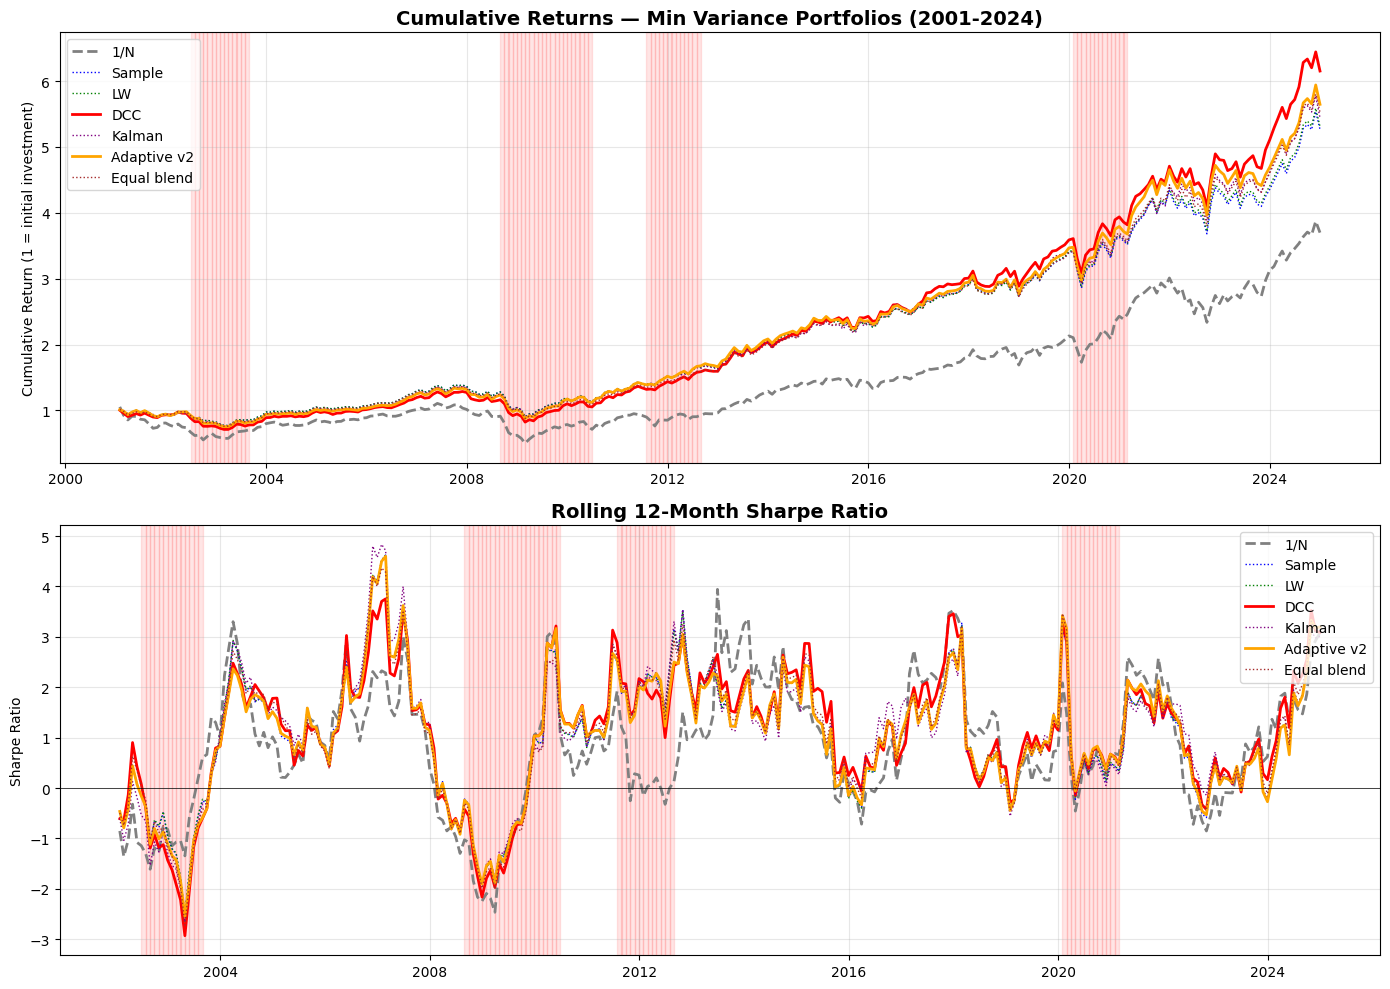

Figure saved


In [45]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# compute cumulative returns for key portfolios
def cumulative_returns(returns_list):
    monthly_rets = np.array([r['monthly_return'] for r in returns_list])
    dates = [r['date'] for r in returns_list]
    cumret = (1 + monthly_rets).cumprod()
    return dates, cumret

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# plot 1 — cumulative returns
ax1 = axes[0]

portfolios_to_plot = {
    '1/N': ew_returns_list,
    'Sample': portfolio_returns['Sigma_sample_mv'],
    'LW': portfolio_returns['Sigma_LW_mv'],
    'DCC': portfolio_returns['Sigma_DCC_mv'],
    'Kalman': portfolio_returns['Sigma_Kalman_mv'],
    'Adaptive v2': portfolio_returns['Sigma_adaptive_v2_mv'],
    'Equal blend': portfolio_returns['Sigma_equal_mv'],
}

colors = ['gray', 'blue', 'green', 'red', 'purple', 'orange', 'brown']
linestyles = ['--', ':', ':', '-', ':', '-', ':']

for (name, rets), color, ls in zip(portfolios_to_plot.items(), colors, linestyles):
    dates, cumret = cumulative_returns(rets)
    dates = pd.to_datetime(dates)
    ax1.plot(dates, cumret, label=name, color=color, 
             linestyle=ls, linewidth=2 if name in ['DCC', 'Adaptive v2', '1/N'] else 1)

ax1.set_title('Cumulative Returns — Min Variance Portfolios (2001-2024)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Return (1 = initial investment)')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# add regime shading
stressed_dates_plot = [results[i]['date'] for i in range(len(results)-1) 
                       if results[i]['regime'] == 1]
for date in stressed_dates_plot:
    ax1.axvspan(pd.to_datetime(date) - pd.DateOffset(months=1),
                pd.to_datetime(date),
                alpha=0.1, color='red')

# plot 2 — rolling 12-month Sharpe
ax2 = axes[1]

for (name, rets), color, ls in zip(portfolios_to_plot.items(), colors, linestyles):
    monthly_rets = np.array([r['monthly_return'] for r in rets])
    dates = pd.to_datetime([r['date'] for r in rets])
    
    # rolling 12-month Sharpe
    rolling_sharpe = []
    rolling_dates = []
    
    for i in range(12, len(monthly_rets)):
        window = monthly_rets[i-12:i]
        s = window.mean() / window.std() * np.sqrt(12) if window.std() > 0 else 0
        rolling_sharpe.append(s)
        rolling_dates.append(dates[i])
    
    ax2.plot(rolling_dates, rolling_sharpe, label=name, color=color,
             linestyle=ls, linewidth=2 if name in ['DCC', 'Adaptive v2', '1/N'] else 1)

ax2.set_title('Rolling 12-Month Sharpe Ratio', fontsize=14, fontweight='bold')
ax2.set_ylabel('Sharpe Ratio')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

# add regime shading to plot 2
for date in stressed_dates_plot:
    ax2.axvspan(pd.to_datetime(date) - pd.DateOffset(months=1),
                pd.to_datetime(date),
                alpha=0.1, color='red')

plt.tight_layout()
plt.savefig('results/figures/cumulative_returns.pdf', 
            bbox_inches='tight', dpi=300)
plt.savefig('results/figures/cumulative_returns.png', 
            bbox_inches='tight', dpi=300)
plt.show()

print("Figure saved")